In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from numpy import meshgrid
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Dataset
from torch.autograd import gradcheck
from numpy import exp, mod, meshgrid, cos, sin, exp, pi
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import shift
from math import sqrt
from scipy.sparse import diags
from scipy.linalg import cholesky

import os
impath = "./data/Wildlandfire_1d/"
immpath = "./plots/Wildlandfire_1d/"
os.makedirs(impath, exist_ok=True)
os.makedirs(immpath, exist_ok=True)

# Crossing waves example

## Create data for example model

In [2]:
seed = 1
np.random.seed(seed)
torch.manual_seed(seed)

dtype  = torch.float32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pretrained_load = True
print(device)

cpu


In [3]:
# Load the wild land fire data
q = np.load('data/Wildlandfire_1d/Original_data/SnapShotMatrix558.49.npy', allow_pickle=True)
X = np.load('data/Wildlandfire_1d/Original_data/1D_Grid.npy', allow_pickle=True)
t = np.load('data/Wildlandfire_1d/Original_data/Time.npy', allow_pickle=True)
x = X[0]
dx = x[1] - x[0]
dt = t[1] - t[0]
Nx = int(np.size(x))
Nt = int(np.size(t))
Q = q[:Nx, :]

# Normalize the input data
Q = (Q - Q.min())/(Q.max() - Q.min())

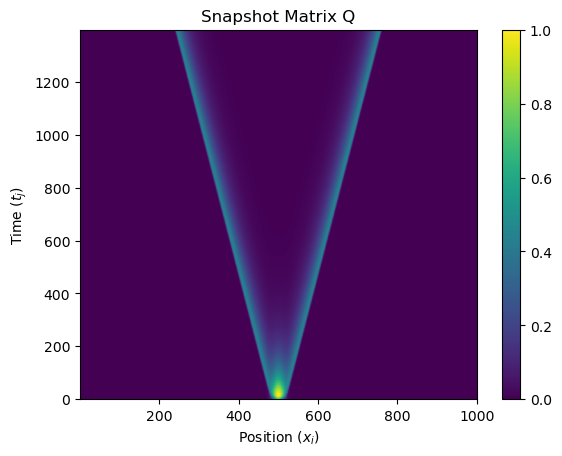

In [4]:
XX, TT = np.meshgrid(x, t)
plt.pcolormesh(XX.T, TT.T, Q)
plt.colorbar()
plt.xlabel('Position ($x_i$)')
plt.ylabel('Time ($t_j$)')
plt.title('Snapshot Matrix Q')
plt.show()

In [5]:
c_left = np.zeros(Nt)
front_pos_left = np.zeros(Nt)
shift_left = np.zeros(Nt)

c_right = np.zeros(Nt)
front_pos_right = np.zeros(Nt)
shift_right = np.zeros(Nt)

for i in range(0, Nt):
    gradVar = np.gradient(Q[:, i], dx, edge_order=2)
    del_t = t[i] - t[0]
    
    front_pos_right[i] = x[np.argmin(gradVar)]  # Right going wave
    front_pos_left[i] = x[np.argmax(gradVar)]  # Left going wave
    
    del_x_left = front_pos_left[i] - front_pos_left[0]
    shift_left[i] = del_x_left
    c_left[i] = (del_x_left / del_t).squeeze()

    del_x_right = front_pos_right[i] - front_pos_right[0]
    shift_right[i] = del_x_right
    c_right[i] = (del_x_right / del_t).squeeze()

c_left[0] = c_left[1]
c_right[0] = c_right[1]

/var/folders/ys/rspl6b551rl9f5w6r8yffqv40000gn/T/ipykernel_62934/3309832213.py:18: RuntimeWarning: invalid value encountered in scalar divide
  c_left[i] = (del_x_left / del_t).squeeze()
/var/folders/ys/rspl6b551rl9f5w6r8yffqv40000gn/T/ipykernel_62934/3309832213.py:22: RuntimeWarning: invalid value encountered in scalar divide
  c_right[i] = (del_x_right / del_t).squeeze()


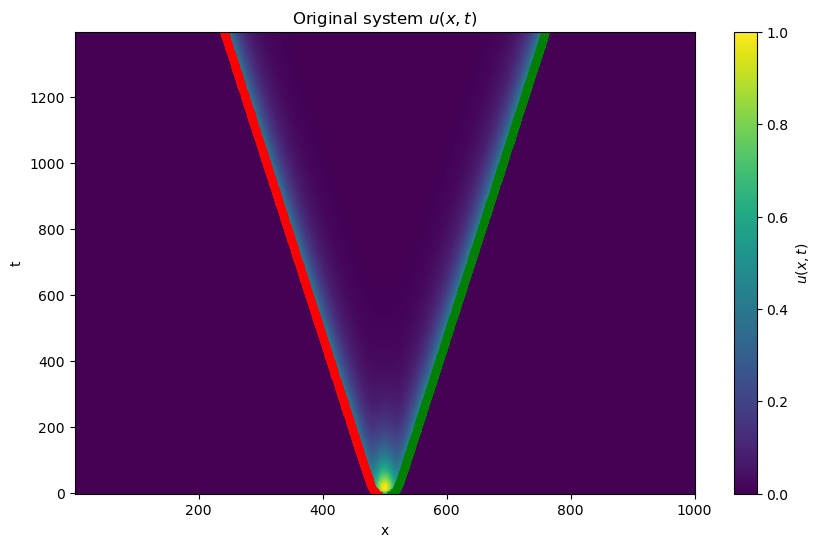

In [6]:
plt.figure(figsize=(10, 6))
plt.pcolormesh(XX.T, TT.T, Q)
plt.colorbar(label=r'$u(x,t)$')
plt.xlabel('x')
plt.ylabel('t')
plt.title(r'Original system $u(x,t)$')
plt.plot(front_pos_left , t, 'r*')
plt.plot(front_pos_right, t, 'g*')
plt.show()

In [7]:
x_device = torch.tensor(x.copy(),  dtype=dtype, device=device)
t_device = torch.tensor(t.copy(),  dtype=dtype, device=device)
center_matrix = torch.tensor(x[-1] // 2, dtype=dtype, device=device)

## Define a model

In [8]:
@torch.jit.script
def nuclear_norm(input_matrix: torch.Tensor) -> torch.Tensor:
    # Forward computation
    return torch.linalg.matrix_norm(input_matrix, ord="nuc")


@torch.jit.script
def nuclear_norm_grad(input_matrix: torch.Tensor, grad_output: torch.Tensor) -> torch.Tensor:
    u, s, v = torch.linalg.svd(input_matrix, full_matrices=False)
    rank = (s > 0).sum().item()
    eye_approx = torch.diag_embed((s > 0).to(input_matrix.dtype)[:rank])
    grad_input = torch.matmul(u[:, :rank], eye_approx)
    grad_input = torch.matmul(grad_input, v[:, :rank].transpose(-2, -1))
    return grad_input * grad_output.unsqueeze(-1).unsqueeze(-1)


class NuclearNormAutograd(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input_matrix):
        ctx.save_for_backward(input_matrix)
        return nuclear_norm(input_matrix)

    @staticmethod
    def backward(ctx, grad_output):
        input_matrix, = ctx.saved_tensors
        return nuclear_norm_grad(input_matrix, grad_output)

In [9]:
class ShapeShiftNet(nn.Module):
    def __init__(self, N_in, N_in_c, N_out, N_out_c, N_hidden, N_layers, x, t, center_matrix):
        super(ShapeShiftNet, self).__init__()

        self.register_buffer('x_flat', x)
        self.register_buffer('t_flat', t)
        self.register_buffer('center_matrix', center_matrix)

        activation = torch.nn.Tanh

        # network for f^1
        self.fc_in_frame1 = torch.nn.Sequential(*[torch.nn.Linear(N_in, N_hidden), activation()])
        # Hidden layers.
        self.hidden_layers_frame1 = torch.nn.Sequential(*[torch.nn.Sequential(*[torch.nn.Linear(N_hidden, N_hidden), activation()])
                                                          for _ in range(N_layers - 1)])
        # Output layer.
        self.fc_out_frame1 = torch.nn.Linear(N_hidden, N_out)


        # network for f^2
        self.fc_in_frame2 = torch.nn.Sequential(*[torch.nn.Linear(N_in, N_hidden), activation()])
        # Hidden layers.
        self.hidden_layers_frame2 = torch.nn.Sequential(*[torch.nn.Sequential(*[torch.nn.Linear(N_hidden, N_hidden), activation()])
                                                          for _ in range(N_layers - 1)])
        # Output layer.
        self.fc_out_frame2 = torch.nn.Linear(N_hidden, N_out)


        # network for f^3
        self.fc_in_frame3 = torch.nn.Sequential(*[torch.nn.Linear(N_in, N_hidden), activation()])
        # Hidden layers.
        self.hidden_layers_frame3 = torch.nn.Sequential(*[torch.nn.Sequential(*[torch.nn.Linear(N_hidden, N_hidden), activation()])
                                                          for _ in range(N_layers - 1)])
        # Output layer.
        self.fc_out_frame3 = torch.nn.Linear(N_hidden, N_out)


        # Shift 1
        # Input layer.
        self.shift_in1 = torch.nn.Sequential(*[torch.nn.Linear(N_in_c, N_hidden), activation()])
        # Hidden layers.
        self.hidden_layers1 = torch.nn.Sequential(*[torch.nn.Sequential(*[torch.nn.Linear(N_hidden, N_hidden), activation()])
                                                          for _ in range(N_layers - 1)])
        # Output layer.
        self.shift_out1 = torch.nn.Linear(N_hidden, N_out_c)


    def forward(self):
        ################################ Shifts ####################################
        c1 = self.shift_in1(self.t_flat)
        for layer in self.hidden_layers1:
            c1 = layer(c1)
        c1 = self.shift_out1(c1)

        ################################ Frames ####################################
        x_shifted1 = self.x_flat - c1 * self.t_flat - self.center_matrix
        f1 = self.fc_in_frame1(torch.cat((x_shifted1, self.t_flat), dim=1))
        for layer in self.hidden_layers_frame1:
            f1 = layer(f1)
        f1 = self.fc_out_frame1(f1)

        x_shifted3 = self.x_flat + c1 * self.t_flat - self.center_matrix
        f3 = self.fc_in_frame3(torch.cat((x_shifted3, self.t_flat), dim=1))
        for layer in self.hidden_layers_frame3:
            f3 = layer(f3)
        f3 = self.fc_out_frame3(f3)



        f1_without_shift = self.fc_in_frame1(torch.cat((self.x_flat - self.center_matrix, self.t_flat), dim=1))
        for layer in self.hidden_layers_frame1:
            f1_without_shift = layer(f1_without_shift)
        f1_without_shift = self.fc_out_frame1(f1_without_shift)

        f2_without_shift = self.fc_in_frame2(torch.cat((self.x_flat - self.center_matrix, self.t_flat), dim=1))
        for layer in self.hidden_layers_frame2:
            f2_without_shift = layer(f2_without_shift)
        f2_without_shift = self.fc_out_frame2(f2_without_shift)

        f3_without_shift = self.fc_in_frame3(torch.cat((self.x_flat - self.center_matrix, self.t_flat), dim=1))
        for layer in self.hidden_layers_frame3:
            f3_without_shift = layer(f3_without_shift)
        f3_without_shift = self.fc_out_frame3(f3_without_shift)

        return f1, f2_without_shift, f3, c1, f1_without_shift, f2_without_shift, f3_without_shift

## Define inputs

In [10]:
x_flat = (x_device).repeat_interleave(Nt).to(device=device, dtype=dtype).view(-1, 1)
t_flat = (t_device).repeat(Nx).to(device=device, dtype=dtype).view(-1, 1)
Q = torch.tensor(Q, dtype=dtype, device=device)

lr = 0.00005
num_epochs = 75000
lambda_star = 0.005
lambda_l1 = 0.05

## Call the model

In [11]:
model = ShapeShiftNet(2, 1, 1, 1, 32, 4, x_flat, t_flat, center_matrix)

if pretrained_load:
    state_dict_original = torch.load("./data/Wildlandfire_1d/Wildlandfire_1d.pth", map_location=torch.device('cpu'))
    state_dict_new = model.state_dict()
    
    for name, param in state_dict_original.items():
        if name in state_dict_new:
            state_dict_new[name].copy_(param)
    model.load_state_dict(state_dict_new, strict=False)
    jit_model = torch.jit.script(model)
    jit_model.to(device)
    delta = 1e-1
else:
    jit_model = torch.jit.script(model)
    jit_model.to(device)
    delta = 1e-5

optimizer = torch.optim.Adam(jit_model.parameters(), lr=lr)

In [ ]:
for epoch in range(num_epochs + 1):
    optimizer.zero_grad()

# Function call for the model
    f1_full, f2_full, f3_full, shift1_pred, f1_full_nos, f2_full_nos, f3_full_nos = jit_model()
    T1Q1 = f1_full.view(Nx, Nt)
    T2Q2 = f2_full.view(Nx, Nt)
    T3Q3 = f3_full.view(Nx, Nt)
    Q1 = f1_full_nos.view(Nx, Nt)
    Q2 = f2_full_nos.view(Nx, Nt)
    Q3 = f3_full_nos.view(Nx, Nt)

    frobenius_loss = torch.linalg.norm(Q - T1Q1 - T2Q2 - T3Q3, 'fro')/ torch.linalg.norm(Q, 'fro')
    l1_loss = lambda_l1 * (torch.linalg.norm(T1Q1, 1) + torch.linalg.norm(T2Q2, 1) + torch.linalg.norm(T3Q3, 1)) / torch.linalg.norm(Q, 1)
    nuclear_loss = lambda_star * (NuclearNormAutograd.apply(Q1) + NuclearNormAutograd.apply(Q2) + NuclearNormAutograd.apply(Q3))
    total_loss = frobenius_loss + nuclear_loss + l1_loss

    total_loss.backward()

    optimizer.step()

    if frobenius_loss < delta:
        print("Early stopping is triggered")
        break
    with torch.no_grad():
        if epoch % 10 == 0:
            print("\n**************************************************************")
            print(f'Epoch {epoch}/{num_epochs}, F: {frobenius_loss.item():.4f}, '
                  f'N: {nuclear_loss.item():.4f}, '
                  f'L1: {l1_loss.item():.4f}, '
                  f'T: {total_loss.item():.4f}')

In [ ]:
# Bring everything back to CPU
Q = Q.cpu().detach().numpy()
Q_tilde = (T1Q1 + T2Q2 + T3Q3).cpu().detach().numpy()
T1Q1 = T1Q1.cpu().detach().numpy()
T2Q2 = T2Q2.cpu().detach().numpy()
T3Q3 = T3Q3.cpu().detach().numpy()
Q1 = Q1.cpu().detach().numpy()
Q2 = Q2.cpu().detach().numpy()
Q3 = Q3.cpu().detach().numpy()
shift1 = front_pos_left.copy()
shift1_numpy = shift1_pred.cpu().detach().numpy()
shift1_numpy_mat = shift1_numpy.reshape(Nx, Nt)
shift1_pred = shift1_numpy * t_flat.cpu().detach().numpy()
shift1_pred_mat = shift1_pred.reshape(Nx, Nt)
shift1_val = shift1_pred_mat.max(axis=0)

In [12]:
Q = np.load(impath + 'Q.npy')
Q_tilde = np.load(impath + 'Q_tilde.npy')
T1Q1 = np.load(impath + 'T1Q1.npy')
T2Q2 = np.load(impath + 'T2Q2.npy')
T3Q3 = np.load(impath + 'T3Q3.npy')
Q1 = np.load(impath + 'Q1.npy')
Q2 = np.load(impath + 'Q2.npy')
Q3 = np.load(impath + 'Q3.npy')
shift1_val = np.load(impath + 'shifts1.npy')
shift1 = np.load(impath + 'shifts1_true.npy')

RecErr: 0.0127639789134264


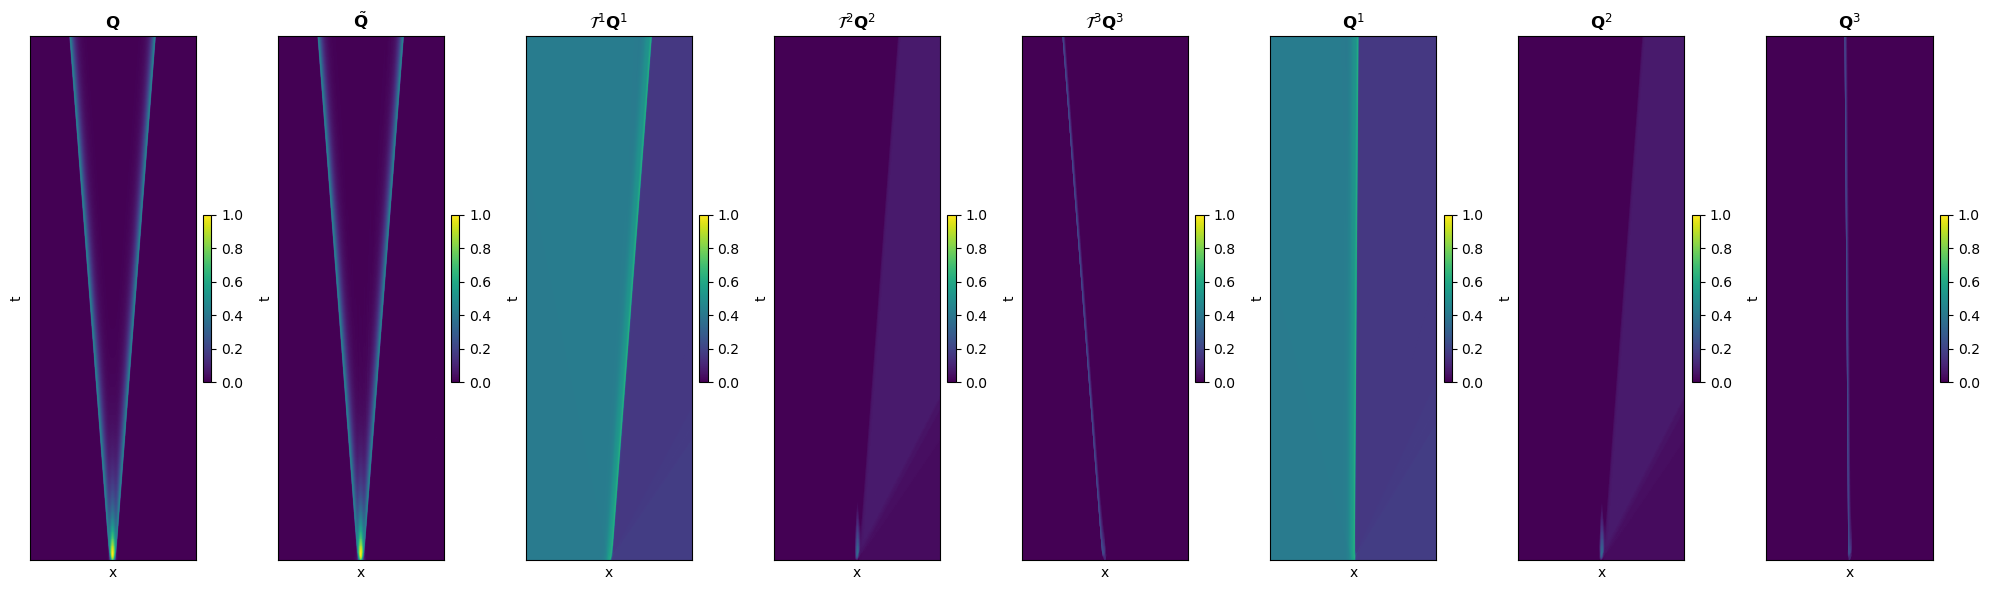

In [13]:
fig, axs = plt.subplots(1, 8, figsize=(20, 6))
vmin = np.min(Q)
vmax = np.max(Q)

im0 = axs[0].pcolormesh(XX.T, TT.T, Q, vmin=vmin, vmax=vmax)
axs[0].set_title(r"${\mathbf{Q}}$")
axs[0].set_xlabel("x")
axs[0].set_ylabel("t")
axs[0].set_xticks([])
axs[0].set_yticks([])
cbar0 = fig.colorbar(im0, ax=axs[0], orientation="vertical", fraction=0.046, pad=0.04)

#Qtilde
im1 = axs[1].pcolormesh(XX.T, TT.T, Q_tilde, vmin=vmin, vmax=vmax)
axs[1].set_title(r"$\tilde{\mathbf{Q}}$")
axs[1].set_xlabel("x")
axs[1].set_ylabel("t")
axs[1].set_xticks([])
axs[1].set_yticks([])
cbar1 = fig.colorbar(im1, ax=axs[1], orientation="vertical", fraction=0.046, pad=0.04)

# T^1Q^1
im2 = axs[2].pcolormesh(XX.T, TT.T, T1Q1, vmin=vmin, vmax=vmax)
axs[2].set_title(r"$\mathcal{T}^1\mathbf{Q}^1$")
axs[2].set_xlabel("x")
axs[2].set_ylabel("t")
axs[2].set_xticks([])
axs[2].set_yticks([])
cbar2 = fig.colorbar(im2, ax=axs[2], orientation="vertical", fraction=0.046, pad=0.04)

# T^2Q^2
im3 = axs[3].pcolormesh(XX.T, TT.T, T2Q2, vmin=vmin, vmax=vmax)
axs[3].set_title(r"$\mathcal{T}^2\mathbf{Q}^2$")
axs[3].set_xlabel("x")
axs[3].set_ylabel("t")
axs[3].set_xticks([])
axs[3].set_yticks([])
cbar3 = fig.colorbar(im3, ax=axs[3], orientation="vertical", fraction=0.046, pad=0.04)

# T^3Q^3
im4 = axs[4].pcolormesh(XX.T, TT.T, T3Q3, vmin=vmin, vmax=vmax)
axs[4].set_title(r"$\mathcal{T}^3\mathbf{Q}^3$")
axs[4].set_xlabel("x")
axs[4].set_ylabel("t")
axs[4].set_xticks([])
axs[4].set_yticks([])
cbar4 = fig.colorbar(im4, ax=axs[4], orientation="vertical", fraction=0.046, pad=0.04)

# Q^1
im5 = axs[5].pcolormesh(XX.T, TT.T, Q1, vmin=vmin, vmax=vmax)
axs[5].set_title(r"$\mathbf{Q}^1$")
axs[5].set_xlabel("x")
axs[5].set_ylabel("t")
axs[5].set_xticks([])
axs[5].set_yticks([])
cbar5 = fig.colorbar(im5, ax=axs[5], orientation="vertical", fraction=0.046, pad=0.04)

# Q^2
im6 = axs[6].pcolormesh(XX.T, TT.T, Q2, vmin=vmin, vmax=vmax)
axs[6].set_title(r"$\mathbf{Q}^2$")
axs[6].set_xlabel("x")
axs[6].set_ylabel("t")
axs[6].set_xticks([])
axs[6].set_yticks([])
cbar6 = fig.colorbar(im6, ax=axs[6], orientation="vertical", fraction=0.046, pad=0.04)

# Q^3
im7 = axs[7].pcolormesh(XX.T, TT.T, Q3, vmin=vmin, vmax=vmax)
axs[7].set_title(r"$\mathbf{Q}^3$")
axs[7].set_xlabel("x")
axs[7].set_ylabel("t")
axs[7].set_xticks([])
axs[7].set_yticks([])
cbar7 = fig.colorbar(im7, ax=axs[7], orientation="vertical", fraction=0.046, pad=0.04)


fig.tight_layout()
fig.savefig(immpath + "Q_opti", dpi=300, transparent=True)

rec_err = np.linalg.norm(Q - T1Q1 - T2Q2 - T3Q3) / np.linalg.norm(Q)
print(f"RecErr: {rec_err}")

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/var/folders/ys/rspl6b551rl9f5w6r8yffqv40000gn/T/ipykernel_62934/286305923.py:2: SyntaxWarning: invalid escape sequence '\m'
  axs.plot(t, shift1_val, label="Predicted shift ($\mathcal{T}^1$)")
/var/folders/ys/rspl6b551rl9f5w6r8yffqv40000gn/T/ipykernel_62934/286305923.py:3: SyntaxWarning: invalid escape sequence '\m'
  axs.plot(t, shift1, label="True shift ($\mathcal{T}^1$)")


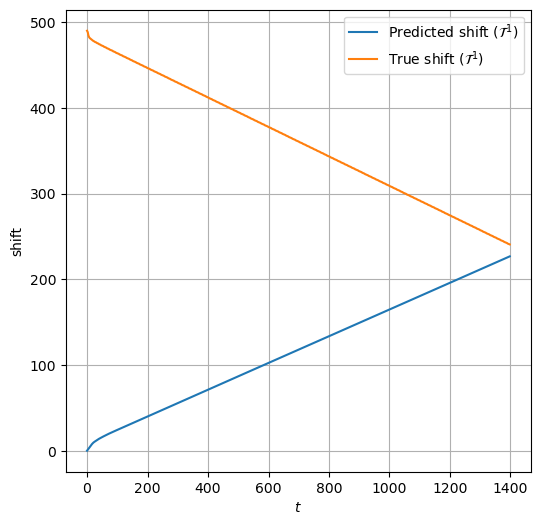

In [14]:
fig, axs = plt.subplots(1, 1, figsize=(6, 6))
axs.plot(t, shift1_val, label="Predicted shift ($\mathcal{T}^1$)")
axs.plot(t, shift1, label="True shift ($\mathcal{T}^1$)")
axs.set_ylabel(r"shift")
axs.set_xlabel(r"$t$")
axs.grid()
axs.legend()
plt.show()

## Saving the results

In [ ]:
torch.save(model.state_dict(), impath + 'Wildlandfire_1d.pth')
np.save(impath + 'Q.npy', Q)
np.save(impath + 'Q_tilde.npy', Q_tilde)
np.save(impath + 'T1Q1.npy', T1Q1)
np.save(impath + 'T2Q2.npy', T2Q2)
np.save(impath + 'T3Q3.npy', T3Q3)
np.save(impath + 'Q1.npy', Q1)
np.save(impath + 'Q2.npy', Q2)
np.save(impath + 'Q3.npy', Q3)
np.save(impath + 'shifts1.npy', shift1_val) 
np.save(impath + 'shifts1_true.npy', shift1)